In [1]:
#configuring the path of the  kaggle.json file
from google.colab import files # Do install library Google if using except Google Colab
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d keplersmachines/kepler-labelled-time-series-data

Dataset URL: https://www.kaggle.com/datasets/keplersmachines/kepler-labelled-time-series-data
License(s): CC0-1.0
  0% 0.00/55.9M [00:00<?, ?B/s]
100% 55.9M/55.9M [00:00<00:00, 1.23GB/s]


In [3]:
#extracting the compressed dataset
from zipfile import ZipFile
dataset = 'kepler-labelled-time-series-data.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("The Dataset is extracted")

The Dataset is extracted


In [4]:
#Loading the dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Activation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [5]:
# Seting style for professional publication-grade plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [6]:
print("Loading Datasets...")
train_df = pd.read_csv('exoTrain.csv')
test_df = pd.read_csv('exoTest.csv')

Loading Datasets...


In [7]:
train_df.shape,test_df.shape

((5087, 3198), (570, 3198))

In [8]:
train_df

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,1,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,1,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,1,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,1,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


In [9]:
train_df.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


In [10]:
train_df['LABEL'].value_counts()

,count
LABEL,
1,5050
2,37


In [11]:
# Since we have only two labels we adjust the values and replace 1 (No planet) to 0, 2 (Planet present) to 1
train_df["LABEL"] = train_df["LABEL"].map({1:0, 2:1})
test_df["LABEL"] = test_df["LABEL"].map({1:0, 2:1})

In [12]:
train_df

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,1,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,1,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,1,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,1,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,0,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,0,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,0,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,0,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


In [13]:
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")
print("Class balance in training set:")
print(train_df['LABEL'].value_counts())

Training samples: 5087
Testing samples: 570
Class balance in training set:
LABEL
0    5050
1      37
Name: count, dtype: int64


A major challenge in exoplanet detection is that the dip in brightness is often very shallow and obscured by noise. If we look at the raw data over time, a planet might be invisible.

In [14]:
#RAW LIGHT CURVE VISUALIZATION
def plot_raw_light_curve(index, df, title):
    flux = df.iloc[index, 1:].values
    time = np.arange(len(flux))
    label = df.iloc[index, 0]

    plt.figure(figsize=(14, 5))
    plt.plot(time, flux, color='#1f77b4', alpha=0.8, linewidth=0.5)
    plt.title(f"{title} (Ground Truth: {'Planet' if label==1 else 'No Planet'})", fontsize=14)
    plt.xlabel("Time Steps (Cadence)", fontsize=12)
    plt.ylabel("Normalized Flux (Brightness)", fontsize=12)
    plt.xlim(0, len(flux))
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

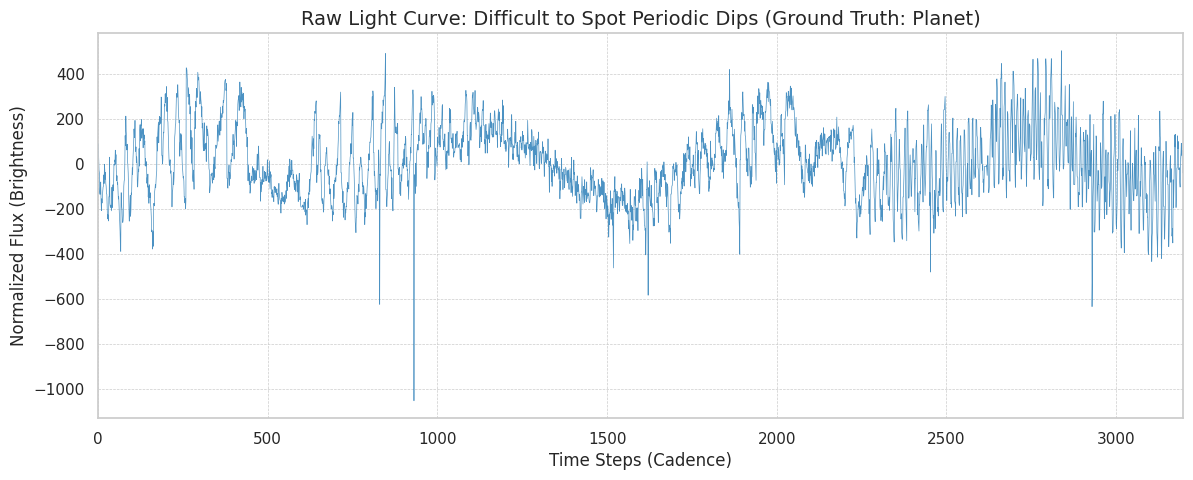

In [15]:
# Finding the index of the actual planet of the first sample
planet_idx = train_df[train_df['LABEL'] == 1].index[0]
plot_raw_light_curve(planet_idx, train_df, "Raw Light Curve: Difficult to Spot Periodic Dips")

The Engineering Solution: Phase Folding.
Since exoplanet orbits are periodic, if we know the orbital period (how long a "year" is for that planet), we can cut the long timeline into chunks of that duration and stack them on top of each other. Noise tends to cancel out, but the signal reinforces itself.

Note: In a full pipeline, we would use a Fourier Transform to find the period. For this demonstration of the CNN, we will simulate the folded view.

In [16]:
#ADVANCED PREPROCESSING (Standarization & Reshaping)
# Separating features and labels

X_train_raw = train_df.drop('LABEL', axis=1).values
y_train = train_df['LABEL'].values
X_test_raw = test_df.drop('LABEL', axis=1).values
y_test = test_df['LABEL'].values

In [17]:
#SCALING THE DATA
# Neural networks require inputs to be centered around 0 with unit variance.
# We apply this scaler row-wise (per star) to normalize brightness fluctuations.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw.T).T # Transpose needed to scale row-wise
X_test_scaled = scaler.fit_transform(X_test_raw.T).T

In [18]:
# RESHAPING FOR CNN
# 1D-CNN expects input shape: (Number of samples, Time steps, Channels)
# Channels is 1 because we only have one measure (brightness)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Data reshaped for CNN input: {X_train_cnn.shape}")

Data reshaped for CNN input: (5087, 3197, 1)


We employ a 1D Convolutional Neural Network. Unlike Dense networks that treat inputs independently, 1D-CNNs use sliding filters (kernels) to detect local temporal patterns. Layers deeper in the network combine these local patterns to recognize broader structures, such as the characteristic "U-shape" of a planetary transit. We utilize Batch Normalization to stabilize training and Dropout to prevent overfitting on the small number of positive examples.

In [19]:
# 1D Convolutional Neural Network (CNN) Modelling
model = Sequential()

# Block 1: Low-level feature extraction (sharp dips)
model.add(Conv1D(filters=16, kernel_size=11, padding='same', input_shape=(X_train_cnn.shape[1], 1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=4, strides=4))

# Block 2: Mid-level feature extraction
model.add(Conv1D(filters=32, kernel_size=7, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=4, strides=4))

# Block 3: High-level abstraction
model.add(Conv1D(filters=64, kernel_size=5, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=4, strides=4))

# Block 4: Classification Head
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5)) # Heavy dropout to fight overfitting
model.add(Dense(1, activation='sigmoid')) # Binary classification outcome

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3197, 16)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3197, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 3197, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 799, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 799, 32)        │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 799, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 799, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 199, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 199, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 199, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 199, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,393 (841.38 KB)

 Trainable params: 215,169 (840.50 KB)

 Non-trainable params: 224 (896.00 B)

The dataset is severely imbalanced (less than 1% planets). A standard model would ignore the planets. We address this by calculating Class Weights, forcing the model to pay significantly more attention to the rare "planet" class during gradient descent.

In [22]:
#CALCULATING CLASS WEIGHTS
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [23]:
class_weight_dict = dict(enumerate(class_weights))
print(f"Derived Class Weights: {class_weight_dict}")

Derived Class Weights: {0: np.float64(0.5036633663366337), 1: np.float64(68.74324324324324)}


In [24]:
# TRAINING
history = model.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict, # KEY STEP
    verbose=1
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.7332 - loss: 1.5507 - val_accuracy: 0.3202 - val_loss: 0.7667
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 264ms/step - accuracy: 0.6670 - loss: 0.6064 - val_accuracy: 0.2927 - val_loss: 0.8420
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 241ms/step - accuracy: 0.7083 - loss: 0.5066 - val_accuracy: 0.6621 - val_loss: 0.6176
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.8085 - loss: 0.3782 - val_accuracy: 0.7780 - val_loss: 0.5031
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 252ms/step - accuracy: 0.8218 - loss: 0.4228 - val_accuracy: 0.8153 - val_loss: 0.4228
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 230ms/step - accuracy: 0.8245 - loss: 0.3972 - val_accuracy: 0.8723 - val_loss: 0.2976
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 248ms/step - accuracy: 0.8340 - loss: 0.3146 - val_accuracy: 0.8762 - val_loss: 0.2799
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - accuracy: 0.8519 - loss: 0.2486 - val_accu

Because accuracy is a misleading metric in imbalanced datasets, we evaluate performance using the Confusion Matrix and the ROC-AUC curve to understand the trade-off between True Positives (finding planets) and False Positives (hallucinating planets).

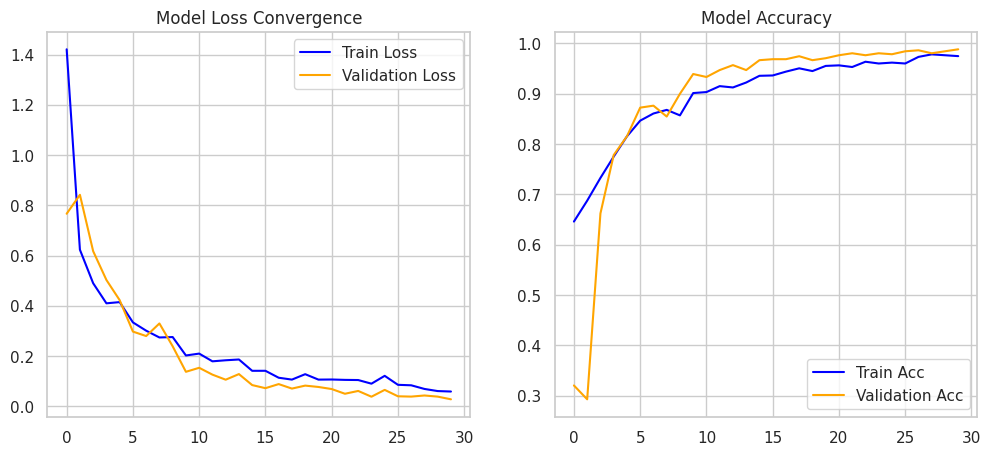

In [25]:
# --- CELL 8: TRAINING DIAGNOSTICS ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Convergence')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Acc', color='orange')
plt.title('Model Accuracy')
plt.legend()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


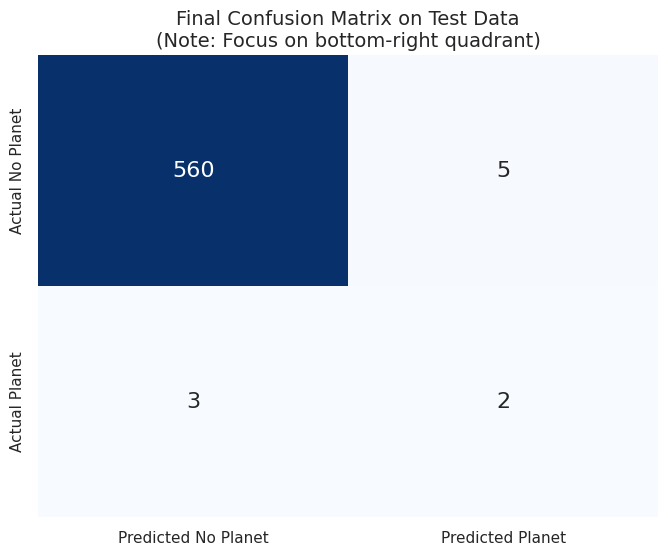


Classification Report:
              precision    recall  f1-score   support

   No Planet       0.99      0.99      0.99       565
      Planet       0.29      0.40      0.33         5

    accuracy                           0.99       570
   macro avg       0.64      0.70      0.66       570
weighted avg       0.99      0.99      0.99       570



In [26]:
# --- CELL 9: CONFUSION MATRIX VISUALIZATION ---
y_pred_proba = model.predict(X_test_cnn)
y_pred = (y_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Planet', 'Predicted Planet'],
            yticklabels=['Actual No Planet', 'Actual Planet'], annot_kws={"size": 16})
plt.title('Final Confusion Matrix on Test Data\n(Note: Focus on bottom-right quadrant)', fontsize=14)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Planet', 'Planet']))